## Projet final Full stack - Auditeur de Cohérence Médicale 🩺
  
### Détection multimodale de cohérence entre radiographie thoracique et compte-rendu médical (📝=🩻 ?)



#### 🎯 Description du projet :  
  
- Auditeur de Cohérence Médicale est un prototype d’IA multimodale qui compare une radiographie thoracique et son compte-rendu associé afin d’estimer leur cohérence.  
Le système produit un score, un niveau de risque et une recommandation de revue humaine.  
Le projet vise à démontrer la faisabilité d’un pipeline data science complet, de la préparation des données à l’évaluation et à la démonstration.  
 

#### 📚 Sources des données :

- Labels et données textuelles (Stanford)
    * Description : Rapport des radiologues au format csv et fichiers de labellisation au format json.
    * Référence : Stanford Machine Learning Group.
    * Lien : [Stanford AIMI Shared Datasets](https://stanfordaimi.azurewebsites.net/datasets/5158c524-d3ab-4e02-96e9-6ee9efc110a1)

- Imageries médicales (Kaggle)
    * Description : Set d'images de radiographies thoraciques au format JPEG.
    * Source : Jeu de données public hébergé sur Kaggle (*CheXpert v1.0 Small*).
    * Lien : [Kaggle Dataset](https://www.kaggle.com/datasets/mimsadiislam/chexpert?select=CheXpert-v1.0-small)  



#### ⚙️ Approche méthodologique :

Pour mener à bien ce projet d'analyse de radiographies, notre démarche se structurera en 3 phases :

- 1. 🏗️ Le pipeline Data Science 
    * ✅ Validation : Vérification de l'intégrité entre les rapports (CSV), les labels (JSON) et les images (Kaggle).
    * 🔍 Analyse Exploratoire (EDA) & Sélection : Étude statistique des pathologies, nettoyage des anomalies et sélection des colonnes clés pour le modèle.
    * ✂️ Préparation des données : Création d'un dataset d'entraînement équilibré, composé de paires cohérentes (vrais rapports/images) et incohérentes (faux appariements générés).


- 2. 🚀 Constitution d'un MVP (Minimum Viable Product)  

    Le MVP a pour objectif de prouver la faisabilité technique du pipeline complet.  
    * 📐 Construction d'une baseline : Mettre en place une baseline multimodale simple, robuste et facilement interprétable.
    * 🧠 Entraînement du modèle : Entraîner un modèle binaire multimodal conçu pour fusionner les caractéristiques textuelles et visuelles afin de produire un **score de cohérence**.
    * 📈 Évaluation : Évaluer les performances du modèle à l'aide de métriques claires et standardisées :
        * *Matrice de confusion* 
        * *Courbe ROC-AUC*
        * *Précision, Rappel & F1-Score*
    * 💻 Démonstration métier : Proposer une interface ou une visualisation claire simulant l'outil en production :  
    image + rapport -> score + risque + action recommandée   


#### 📂 Structure et Hiérarchie des Données

Afin d'assurer le bon fonctionnement du pipeline, les données doivent être organisées à la racine du notebook selon l'arborescence suivante :

```text
. (Racine du notebook)
└── CheXpert/
    ├── df_chexpert_plus_240401.csv    # Fichier principal contenant les rapports textuels
    ├── chexbert_labels/
    │   └── impression_fixed.json      # Labels générés/structurés pour CheXbert
    └── CheXpert-v1.0-small/           # Répertoire principal des imageries médicales
        ├── train/                     # Images de radiographies pour l'entraînement
        └── valid/                     # Images de radiographies pour la validation

> 📌 **Portée de ce Notebook :** Ce présent document est exclusivement dédié à la **Partie 1 : Le pipeline Data Science** (Validation, EDA, Sélection et Préparation). Les phases d'entraînement du modèle multimodal et d'évaluation feront l'objet d'un ou plusieurs livrables/notebooks ultérieur.

### ✅ Validation  
Vérification de l'intégrité entre les rapports (CSV), les labels (JSON) et les images (Kaggle).

In [195]:
# Import librairies

import os
import json
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
import io
import random


In [196]:
# Chemins d'accès aux sources

BASE_DIR = os.getcwd()
PATH_CSV = os.path.join(BASE_DIR, "CheXpert")
PATH_IMAGES = os.path.join(BASE_DIR, "CheXpert", "CheXpert-v1.0-small")
PATH_JSON = os.path.join(BASE_DIR, "CheXpert", "chexbert_labels")


In [197]:
# Fonction de chargement CSV et JSON

def chargement_csv_json(fichier_csv, fichier_json):
    
    # Ouverture CSV
    print(f"Chargement du CSV : {fichier_csv}")
    adresse_csv = os.path.join(PATH_CSV, fichier_csv)
    df_csv = pd.read_csv(adresse_csv)
    display(df_csv.head(5))

    # Ouverture JSON
    adresse_json = os.path.join(PATH_JSON, fichier_json)
    print(f"Chargement du JSON : {adresse_json}")
    json_lines_list = []
    with open(adresse_json, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                data_chunk = json.loads(line)
                if isinstance(data_chunk, dict):
                    json_lines_list.append(data_chunk)
            except json.JSONDecodeError:
                continue
    # Conversion du json en dataframe
    df_json = pd.DataFrame(json_lines_list)
    display(df_json.head(5))

    # Fusion sur la clé commune 'path_to_image'
    print("Fusion des DataFrames sur la clé 'path_to_image'...")
    df_fusionne = pd.merge(df_csv, df_json, on='path_to_image', how='left', indicator=True)
    df_fusionne["jointure_csv_json"] = df_fusionne["_merge"].map({"both": "OK", "left_only": "PB"})
    df_fusionne = df_fusionne.drop(columns=["_merge"])

    display(df_fusionne.head(5))

    # Affichage stats
    nb_rapport = len(df_csv)
    print(f"Nombre de lignes csv : {nb_rapport}")
    nb_json = len(df_json)
    print(f"Nombre de lignes json : {nb_json}")
    nb_fusion = len(df_fusionne)
    print(f"Nombre de lignes jointure csv + json : {nb_fusion}")
    nb_ok = (df_fusionne["jointure_csv_json"] == "OK").sum()
    print(f"Nombre de lignes avec jointure ok : {nb_ok}")

    # Ouverture image
    def verifier_existence_image(path_to_image, dossier_racine):
        chemin_complet_disque = os.path.normpath(os.path.join(dossier_racine, path_to_image))
        if os.path.exists(chemin_complet_disque):
            return path_to_image 
        else:
            return None

    df_fusionne["chemin_image"] = df_fusionne["path_to_image"].apply(
        lambda x: verifier_existence_image(x,PATH_IMAGES )
        ) 
    
    nb_image_ok = df_fusionne["chemin_image"].notna().sum()
    print(f"Nombre de lignes avec image : {nb_image_ok}")
        
    return df_fusionne, df_csv, df_json
    

In [198]:
FICHIER_CSV = "df_chexpert_plus_240401.csv"
FICHIER_JSON = "impression_fixed.json"

dataset_trav, dataset_csv, dataset_json = chargement_csv_json(FICHIER_CSV, FICHIER_JSON)



Chargement du CSV : df_chexpert_plus_240401.csv


,path_to_image,path_to_dcm,frontal_lateral,ap_pa,deid_patient_id,patient_report_date_order,report,section_narrative,section_clinical_history,section_history,...,section_accession_number,age,sex,race,ethnicity,interpreter_needed,insurance_type,recent_bmi,deceased,split
0,train/patient42142/study5/view1_frontal.jpg,train/patient42142/study5/view1_frontal.dcm,Frontal,AP,patient42142,5,"NARRATIVE:\nChest 1 View, 8-8-2005\n \nHISTORY...","\nChest 1 View, 8-8-2005\n \n",NaN,"61 years Female, ICU patient\n \n",...,\n 9959089\nThis report has been anonymized. A...,62.0,Female,White,Non-Hispanic/Non-Latino,No,Private Insurance,22.2,No,train
1,train/patient42142/study8/view1_frontal.jpg,train/patient42142/study8/view1_frontal.dcm,Frontal,AP,patient42142,8,"NARRATIVE:\nChest 1 View, 7-11-2000\n \nHISTOR...","\nChest 1 View, 7-11-2000\n \n",NaN,"61 years Female, tracheostomy.\n \n",...,\n64048857\nThis report has been anonymized. A...,62.0,Female,White,Non-Hispanic/Non-Latino,No,Private Insurance,22.2,No,train
2,train/patient42142/study2/view1_frontal.jpg,train/patient42142/study2/view1_frontal.dcm,Frontal,AP,patient42142,2,"NARRATIVE:\nChest 1 View, 11-17-2018\n \nHISTO...","\nChest 1 View, 11-17-2018\n \n",NaN,"61 years Female, critical care follow-up\n \n",...,\n#2452\nThis report has been anonymized. All ...,62.0,Female,White,Non-Hispanic/Non-Latino,No,Private Insurance,22.2,No,train
3,train/patient42142/study4/view1_frontal.jpg,train/patient42142/study4/view1_frontal.dcm,Frontal,AP,patient42142,4,NARRATIVE:\nAP PORTABLE UPRIGHT CHEST: May 01 ...,\nAP PORTABLE UPRIGHT CHEST: May 01 at 0518 ho...,ICU protocol. Follow up.\n \n,NaN,...,\n4164064\nThis report has been anonymized. Al...,62.0,Female,White,Non-Hispanic/Non-Latino,No,Private Insurance,22.2,No,train
4,train/patient42142/study3/view1_frontal.jpg,train/patient42142/study3/view1_frontal.dcm,Frontal,AP,patient42142,3,"NARRATIVE:\nEXAM: Chest 1 View, 10/4/2\n \nCLI...","\nEXAM: Chest 1 View, 10/4/2\n \n",61 years Female UPRIGHT PLEASE. ICU PROTOCOL ...,NaN,...,\n49286401\nThis report has been anonymized. A...,62.0,Female,White,Non-Hispanic/Non-Latino,No,Private Insurance,22.2,No,train


Chargement du JSON : c:\Données\FORMATION\fullstack\ProjetFinal\CheXpert\chexbert_labels\impression_fixed.json


,path_to_image,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices,No Finding
0,train/patient42142/study5/view1_frontal.jpg,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,1.0,NaN
1,train/patient42142/study8/view1_frontal.jpg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,NaN,NaN,NaN,1.0,NaN
2,train/patient42142/study2/view1_frontal.jpg,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0,NaN,1.0,NaN,NaN,1.0,NaN
3,train/patient42142/study4/view1_frontal.jpg,NaN,0.0,NaN,NaN,NaN,-1.0,NaN,1.0,NaN,NaN,NaN,NaN,1.0,NaN
4,train/patient42142/study3/view1_frontal.jpg,NaN,NaN,NaN,NaN,0.0,0.0,NaN,1.0,NaN,0.0,NaN,NaN,1.0,NaN


Fusion des DataFrames sur la clé 'path_to_image'...


,path_to_image,path_to_dcm,frontal_lateral,ap_pa,deid_patient_id,patient_report_date_order,report,section_narrative,section_clinical_history,section_history,...,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices,No Finding,jointure_csv_json
0,train/patient42142/study5/view1_frontal.jpg,train/patient42142/study5/view1_frontal.dcm,Frontal,AP,patient42142,5,"NARRATIVE:\nChest 1 View, 8-8-2005\n \nHISTORY...","\nChest 1 View, 8-8-2005\n \n",NaN,"61 years Female, ICU patient\n \n",...,NaN,NaN,NaN,0.0,0.0,NaN,NaN,1.0,NaN,OK
1,train/patient42142/study8/view1_frontal.jpg,train/patient42142/study8/view1_frontal.dcm,Frontal,AP,patient42142,8,"NARRATIVE:\nChest 1 View, 7-11-2000\n \nHISTOR...","\nChest 1 View, 7-11-2000\n \n",NaN,"61 years Female, tracheostomy.\n \n",...,NaN,NaN,1.0,0.0,NaN,NaN,NaN,1.0,NaN,OK
2,train/patient42142/study2/view1_frontal.jpg,train/patient42142/study2/view1_frontal.dcm,Frontal,AP,patient42142,2,"NARRATIVE:\nChest 1 View, 11-17-2018\n \nHISTO...","\nChest 1 View, 11-17-2018\n \n",NaN,"61 years Female, critical care follow-up\n \n",...,NaN,NaN,1.0,NaN,1.0,NaN,NaN,1.0,NaN,OK
3,train/patient42142/study4/view1_frontal.jpg,train/patient42142/study4/view1_frontal.dcm,Frontal,AP,patient42142,4,NARRATIVE:\nAP PORTABLE UPRIGHT CHEST: May 01 ...,\nAP PORTABLE UPRIGHT CHEST: May 01 at 0518 ho...,ICU protocol. Follow up.\n \n,NaN,...,-1.0,NaN,1.0,NaN,NaN,NaN,NaN,1.0,NaN,OK
4,train/patient42142/study3/view1_frontal.jpg,train/patient42142/study3/view1_frontal.dcm,Frontal,AP,patient42142,3,"NARRATIVE:\nEXAM: Chest 1 View, 10/4/2\n \nCLI...","\nEXAM: Chest 1 View, 10/4/2\n \n",61 years Female UPRIGHT PLEASE. ICU PROTOCOL ...,NaN,...,0.0,NaN,1.0,NaN,0.0,NaN,NaN,1.0,NaN,OK


Nombre de lignes csv : 223462
Nombre de lignes json : 223462
Nombre de lignes jointure csv + json : 223462
Nombre de lignes avec jointure ok : 223462
Nombre de lignes avec image : 223462


On constate qu'on a bien une cohérence entre les différentes sources : rapport / label / image

### 🔍 Analyse Exploratoire (EDA) & Sélection  
Étude statistique des pathologies, nettoyage des anomalies et sélection des colonnes clés pour le modèle.

In [199]:
display(dataset_trav.head(5))        

,path_to_image,path_to_dcm,frontal_lateral,ap_pa,deid_patient_id,patient_report_date_order,report,section_narrative,section_clinical_history,section_history,...,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices,No Finding,jointure_csv_json,chemin_image
0,train/patient42142/study5/view1_frontal.jpg,train/patient42142/study5/view1_frontal.dcm,Frontal,AP,patient42142,5,"NARRATIVE:\nChest 1 View, 8-8-2005\n \nHISTORY...","\nChest 1 View, 8-8-2005\n \n",NaN,"61 years Female, ICU patient\n \n",...,NaN,NaN,0.0,0.0,NaN,NaN,1.0,NaN,OK,train/patient42142/study5/view1_frontal.jpg
1,train/patient42142/study8/view1_frontal.jpg,train/patient42142/study8/view1_frontal.dcm,Frontal,AP,patient42142,8,"NARRATIVE:\nChest 1 View, 7-11-2000\n \nHISTOR...","\nChest 1 View, 7-11-2000\n \n",NaN,"61 years Female, tracheostomy.\n \n",...,NaN,1.0,0.0,NaN,NaN,NaN,1.0,NaN,OK,train/patient42142/study8/view1_frontal.jpg
2,train/patient42142/study2/view1_frontal.jpg,train/patient42142/study2/view1_frontal.dcm,Frontal,AP,patient42142,2,"NARRATIVE:\nChest 1 View, 11-17-2018\n \nHISTO...","\nChest 1 View, 11-17-2018\n \n",NaN,"61 years Female, critical care follow-up\n \n",...,NaN,1.0,NaN,1.0,NaN,NaN,1.0,NaN,OK,train/patient42142/study2/view1_frontal.jpg
3,train/patient42142/study4/view1_frontal.jpg,train/patient42142/study4/view1_frontal.dcm,Frontal,AP,patient42142,4,NARRATIVE:\nAP PORTABLE UPRIGHT CHEST: May 01 ...,\nAP PORTABLE UPRIGHT CHEST: May 01 at 0518 ho...,ICU protocol. Follow up.\n \n,NaN,...,NaN,1.0,NaN,NaN,NaN,NaN,1.0,NaN,OK,train/patient42142/study4/view1_frontal.jpg
4,train/patient42142/study3/view1_frontal.jpg,train/patient42142/study3/view1_frontal.dcm,Frontal,AP,patient42142,3,"NARRATIVE:\nEXAM: Chest 1 View, 10/4/2\n \nCLI...","\nEXAM: Chest 1 View, 10/4/2\n \n",61 years Female UPRIGHT PLEASE. ICU PROTOCOL ...,NaN,...,NaN,1.0,NaN,0.0,NaN,NaN,1.0,NaN,OK,train/patient42142/study3/view1_frontal.jpg


In [200]:
# Extraction du numéro de l'étude
dataset_trav["numero_etude"] = (
    dataset_trav["path_to_image"].str.extract(r"study(\d+)")
)
# Aperçu du résultat
print(dataset_trav[["path_to_image",  "numero_etude"]].head())

                                 path_to_image numero_etude
0  train/patient42142/study5/view1_frontal.jpg            5
1  train/patient42142/study8/view1_frontal.jpg            8
2  train/patient42142/study2/view1_frontal.jpg            2
3  train/patient42142/study4/view1_frontal.jpg            4
4  train/patient42142/study3/view1_frontal.jpg            3


In [201]:
# Affichage stat sur chaque colonne trié par taux de remplissage décroissant

total_lignes = len(dataset_trav)
valeurs_renseignees = dataset_trav.count()
valeurs_uniques = dataset_trav.nunique()
valeurs_non_uniques = valeurs_renseignees - valeurs_uniques

df_recap = pd.DataFrame(
    {
        "Valeurs renseignées": valeurs_renseignees,
        "Valeurs uniques": valeurs_uniques,
        "Valeurs non uniques (doublons)": valeurs_non_uniques,
    }
)

df_recap["Valeurs manquantes"] = len(dataset_trav) - valeurs_renseignees
df_recap["Taux de remplissage (%)"] = ((valeurs_renseignees / total_lignes) * 100).round(2)
df_recap = df_recap.sort_values(by="Taux de remplissage (%)", ascending=False)
display(df_recap)




,Valeurs renseignées,Valeurs uniques,Valeurs non uniques (doublons),Valeurs manquantes,Taux de remplissage (%)
path_to_image,223462,223462,0,0,100.00
path_to_dcm,223462,223462,0,0,100.00
frontal_lateral,223462,2,223460,0,100.00
deid_patient_id,223462,64725,158737,0,100.00
report,223462,223460,2,0,100.00
patient_report_date_order,223462,92,223370,0,100.00
interpreter_needed,223462,3,223459,0,100.00
insurance_type,223462,5,223457,0,100.00
deceased,223462,3,223459,0,100.00
split,223462,2,223460,0,100.00


A première vue on constate que nous avons :  
- un taux de remplissage de 100% pour 'report' et conséquent pour 'section_impression'
- un taux de remplissage pauvre pour certaines section (technique, procedure_comments, history ...)
- pas de doublon pour 'path_to_image'
- peu d'études uniques
- 2 'report' identique 

Pour le cas des 2 rapports identiques comme nous avons un 'path_to_image' différent, on considère ces lignes comme des cas normaux et ne sont donc pas exclus

Nous allons maintenant compter le nombre d'études et d'images par patient

In [202]:
# Stats nb d'études et d'images par patient
from IPython.display import display

# nombre d'images pour chaque étude de chaque patient
df_images_par_etude = (
    dataset_trav.groupby(["deid_patient_id", "numero_etude"])
    .size()
    .reset_index(name="nb_image_par_etude")
)

# nombre total d'études uniques pour chaque patient
df_etudes_par_patient = (
    df_images_par_etude.groupby("deid_patient_id")
    .size()
    .reset_index(name="nb_etude_par_patient")
)

# Fusion deux informations
df_complet = pd.merge(df_images_par_etude, df_etudes_par_patient, on="deid_patient_id")

# Regroupement par les deux critères pour compter les patients uniques
df_recap_final = (
    df_complet.groupby(["nb_etude_par_patient", "nb_image_par_etude"])
    .agg(Nombre_de_patient=("deid_patient_id", "nunique"))
    .reset_index()
)

# Réorganisation des colonnes
df_recap_final = df_recap_final[
    ["nb_etude_par_patient", "nb_image_par_etude", "Nombre_de_patient"]
]
df_recap_final.columns = [
    "Nb d'études/patient",
    "Nb d'images/étude",
    "Nombre de patient",
]

# Tri 
df_recap_final = df_recap_final.sort_values(
    ["Nb d'études/patient", "Nb d'images/étude"]
)

display(df_recap_final)

,Nb d'études/patient,Nb d'images/étude,Nombre de patient
0,1,1,22766
1,1,2,10419
2,1,3,579
3,2,1,10116
4,2,2,3826
...,...,...,...
183,86,1,1
184,86,2,1
185,89,1,1
186,91,1,1


Afin d'éviter un data leakage nous allons sélectionner que les patients ayant une seule étude avec une seule radio pour être certain de ne pas avoir de patient qui serait en même temps dans le train, le valid ou le test du split à venir.  
De plus cela 'simplifiera' la démarche des modèles car nous excluons de ce fait les rapports basés sur plusieurs images impliquant des architectures de deep-learning plus complexes.

In [203]:
patients_cibles = df_complet[
    (df_complet["nb_etude_par_patient"] == 1)
    & (df_complet["nb_image_par_etude"] == 1)
]
print (len(patients_cibles))

dataset_trav_cible = dataset_trav[
    dataset_trav["deid_patient_id"].isin(patients_cibles["deid_patient_id"])
].copy()

print(len(dataset_trav_cible))


22766
22766


Nous allons désormais étudier de plus près les pathologies

TAUX DE POSITIVITÉ PATHOLOGIE


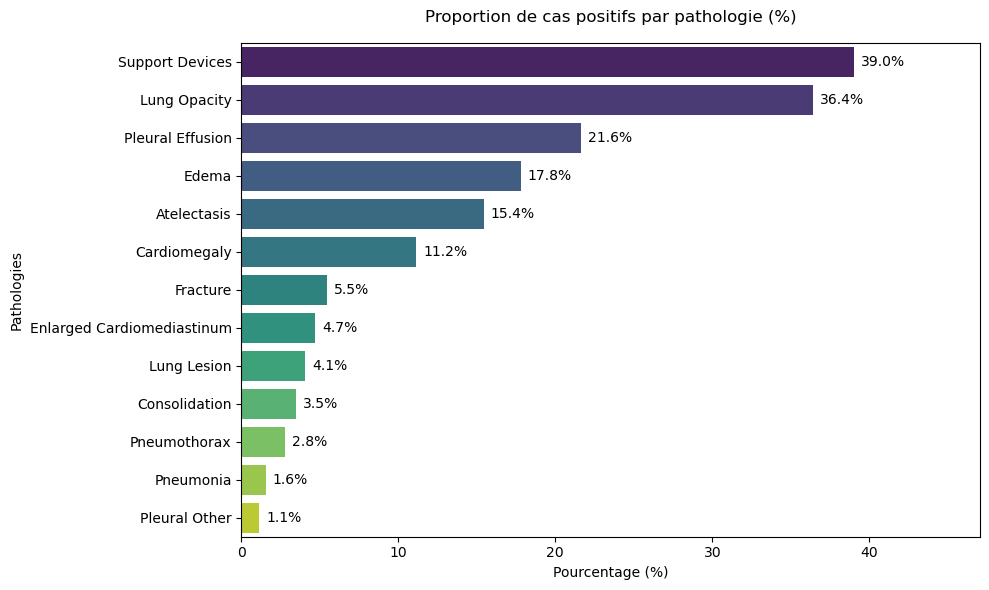

In [204]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Liste des pathologies (on exclut 'No Findings')
pathologies_cols = [
    "Enlarged Cardiomediastinum",
    "Cardiomegaly",
    "Lung Opacity",
    "Lung Lesion",
    "Edema",
    "Consolidation",
    "Pneumonia",
    "Atelectasis",
    "Pneumothorax",
    "Pleural Effusion",
    "Pleural Other",
    "Fracture",
    "Support Devices",
]

print("TAUX DE POSITIVITÉ PATHOLOGIE")
taux_positivite = (dataset_trav_cible[pathologies_cols] == 1).mean() * 100
taux_positivite = taux_positivite.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    x=taux_positivite.values,
    y=taux_positivite.index,
    hue=taux_positivite.index,
    palette="viridis",
    legend=False,
    ax=ax,
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=5, fontsize=10)

plt.title("Proportion de cas positifs par pathologie (%)", fontsize=12, pad=15)
plt.xlabel("Pourcentage (%)")
plt.ylabel("Pathologies")
plt.xlim(0, taux_positivite.max() + 8)
plt.tight_layout()
plt.show()


On constate que 39% des rapports ont une pathologie 'Support Devices'  
En fait celle-ci n'est pas vraiment une pathologie mais une indication s'il y a présence d'un appareil (cathéther, tubes ...)


 DISTRIBUTION MULTI-PATHOLOGIE


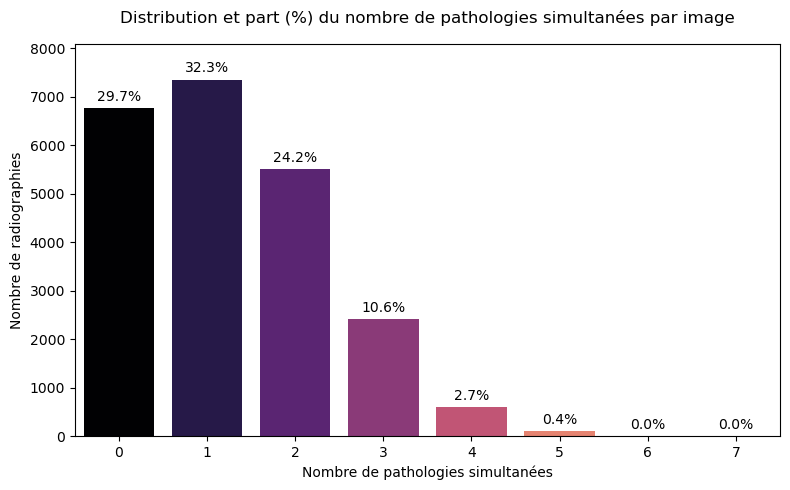

In [205]:
vraies_pathologies_cols = [
    col for col in pathologies_cols if col != "Support Devices"
]

print("\n DISTRIBUTION MULTI-PATHOLOGIE")
nb_pathologies_par_image = (dataset_trav_cible[vraies_pathologies_cols] == 1).sum(axis=1)

total_images = len(dataset_trav_cible)
counts = nb_pathologies_par_image.value_counts().sort_index()
proportions = (counts / total_images) * 100

fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(
    x=nb_pathologies_par_image,
    hue=nb_pathologies_par_image,
    palette="magma",
    legend=False,
    ax=ax,
)

for i, p in enumerate(ax.patches):
    if i < len(proportions):
        height = p.get_height()
        ax.annotate(
            f"{proportions.iloc[i]:.1f}%",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="center",
            xytext=(0, 8),
            textcoords="offset points",
            fontsize=10,
        )

plt.title(
    "Distribution et part (%) du nombre de pathologies simultanées par image",
    fontsize=12,
    pad=15,
)
plt.xlabel("Nombre de pathologies simultanées")
plt.ylabel("Nombre de radiographies")
# On augmente légèrement la limite de l'axe Y pour ne pas coller au titre
plt.ylim(0, counts.max() * 1.1)
plt.tight_layout()
plt.show()

Vérifions maintenant la véracité de 'No findings'  
Celui-ci doit être à 1 si la somme de toutes les pathologies sont à 0 (aucune pathologie détectée)
Sinon il doit être à 0

EXHAUSTIVITÉ DE LA VARIABLE 'NO FINDING' (AVEC NAN)


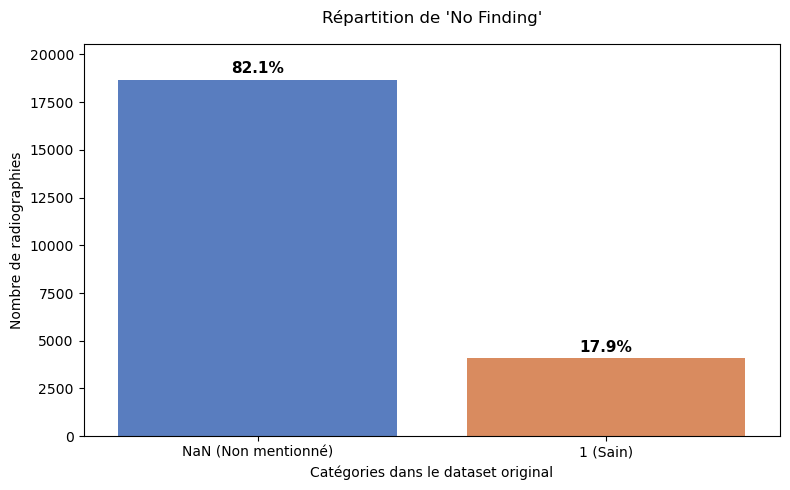

In [206]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

print("EXHAUSTIVITÉ DE LA VARIABLE 'NO FINDING' (AVEC NAN)")

no_finding_3_blocks = dataset_trav_cible["No Finding"].map(
    {1.0: "1 (Sain)", 0.0: "0 (Pathologique)"}
).fillna("NaN (Non mentionné)")

counts = no_finding_3_blocks.value_counts()
proportions = (counts / len(dataset_trav_cible)) * 100

x_labels = counts.index.tolist()

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    x=x_labels,
    y=counts.values,
    hue=x_labels,
    palette="muted",
    legend=False,
    ax=ax,
)

for i, p in enumerate(ax.patches):
    if i < len(proportions):
        height = p.get_height()
        ax.annotate(
            f"{proportions.iloc[i]:.1f}%",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="center",
            xytext=(0, 8),
            textcoords="offset points",
            fontsize=11,
            weight="bold",
        )

plt.title(
    "Répartition de 'No Finding'",
    fontsize=12,
    pad=15,
)
plt.ylabel("Nombre de radiographies")
plt.xlabel("Catégories dans le dataset original")
plt.ylim(0, counts.max() * 1.1)
plt.tight_layout()
plt.show()

In [207]:
df_sains_theoriques = dataset_trav_cible[dataset_trav_cible["No Finding"] == 1]

nb_pathologies_detectees = (df_sains_theoriques[vraies_pathologies_cols] == 1).sum(axis=1)

lignes_avec_anomalies = df_sains_theoriques[nb_pathologies_detectees > 0]
nb_anomalies = len(lignes_avec_anomalies)

print("RAPPORT DE COHÉRENCE SUR LES CAS 'SAINS'")
print(f"Nombre de cas analysés (No Finding == 1) : {len(df_sains_theoriques)}")

if nb_anomalies == 0:
    print("\n✅ COHÉRENCE TOTALE (100%) :")
else:
    print(f"\n⚠️ ATTENTION : {nb_anomalies} anomalies détectées !")
    print("Certaines lignes sont marquées 'Saines' mais ont quand même des pathologies à 1.")
    
    # Affichage des lignes problématiques pour comprendre l'erreur
    print("\nAperçu des anomalies :")
    display(lignes_avec_anomalies[["path_to_image", "No Finding"] + vraies_pathologies_cols].head(5))

RAPPORT DE COHÉRENCE SUR LES CAS 'SAINS'
Nombre de cas analysés (No Finding == 1) : 4081

⚠️ ATTENTION : 30 anomalies détectées !
Certaines lignes sont marquées 'Saines' mais ont quand même des pathologies à 1.

Aperçu des anomalies :


,path_to_image,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture
18287,train/patient49595/study1/view1_frontal.jpg,1.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,1.0,0.0,0.0,NaN,NaN
28743,train/patient54491/study1/view1_frontal.jpg,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,NaN,NaN,NaN
138648,train/patient04417/study1/view1_frontal.jpg,1.0,0.0,NaN,NaN,NaN,NaN,0.0,NaN,1.0,0.0,0.0,NaN,NaN
143589,train/patient50373/study1/view1_frontal.jpg,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,NaN,NaN,NaN
146313,train/patient51684/study1/view1_frontal.jpg,1.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,1.0,NaN,0.0,NaN,NaN


DISTRIBUTION DES ÂGES


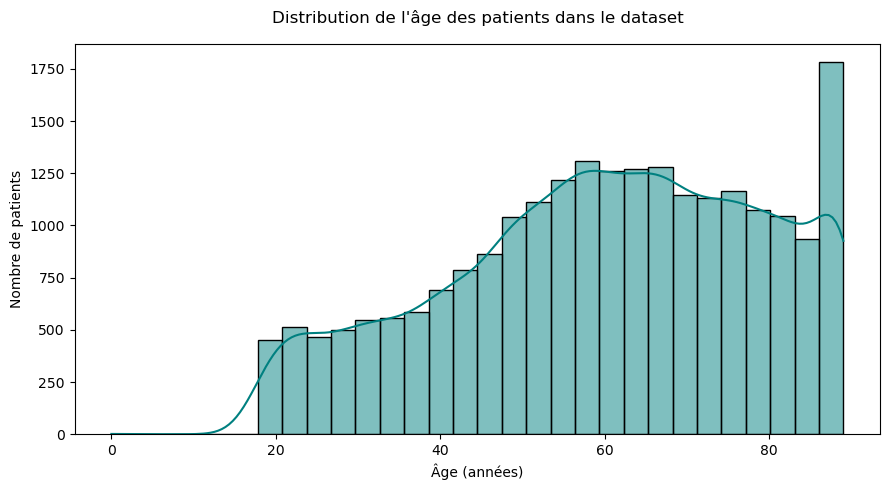

Âge médian  : 61.0 ans | Âge moyen   : 59.8 ans
Âge minimum : 0.0 ans  | Âge maximum : 89.0 ans


In [208]:
import matplotlib.pyplot as plt
import seaborn as sns

print("DISTRIBUTION DES ÂGES")

plt.figure(figsize=(9, 5))
# Utilisation de histplot pour voir la distribution continue de l'âge
sns.histplot(data=dataset_trav_cible, x="age", bins=30, kde=True, color="teal")

plt.title("Distribution de l'âge des patients dans le dataset", fontsize=12, pad=15)
plt.xlabel("Âge (années)")
plt.ylabel("Nombre de patients")
plt.tight_layout()
plt.show()

print(f"Âge médian  : {dataset_trav_cible['age'].median():.1f} ans | Âge moyen   : {dataset_trav_cible['age'].mean():.1f} ans")
print(f"Âge minimum : {dataset_trav_cible['age'].min()} ans  | Âge maximum : {dataset_trav_cible['age'].max()} ans")

In [209]:
# Stats par tranche d'age par 10
bornes = range(-1, 101, 10)

labels = [f"{i+1}-{i+10} ans" for i in range(0, 100, 10)]
labels[0] = "0-9 ans"

dataset_trav_cible["tranche_age"] = pd.cut(
    dataset_trav_cible["age"], bins=bornes, labels=labels
)

effectifs = dataset_trav_cible["tranche_age"].value_counts().sort_index()

pourcentages = (
    (dataset_trav_cible["tranche_age"].value_counts(normalize=True) * 100)
    .round(1)
    .sort_index()
)

df_repartition_age = pd.DataFrame(
    {"Nombre de patients": effectifs, "Proportion (%)": pourcentages}
)

display(df_repartition_age)

,Nombre de patients,Proportion (%)
tranche_age,,
0-9 ans,3,0.0
11-20 ans,307,1.4
21-30 ans,1630,7.2
31-40 ans,1913,8.4
41-50 ans,2794,12.3
51-60 ans,4000,17.6
61-70 ans,4229,18.6
71-80 ans,3721,16.4
81-90 ans,4135,18.2


In [210]:
# Combien de lignes ont un âge égal à 0 ?
cas_age_zero = dataset_trav[dataset_trav["age"] == 0]
print(f"Nombre de cas où l'âge est 0 : {len(cas_age_zero)}")

display(cas_age_zero[["path_to_image", "sex", "Support Devices", "No Finding"]].head(10))

Nombre de cas où l'âge est 0 : 3


,path_to_image,sex,Support Devices,No Finding
187120,train/patient64539/study1/view1_frontal.jpg,Female,NaN,NaN
208208,train/patient64538/study1/view1_frontal.jpg,Female,NaN,NaN
219091,train/patient64540/study1/view1_frontal.jpg,Female,NaN,1.0


Sélection des colonnes :  
- 'path_to_image'  
- 'deid_patient_id'  
- 'report'  
- 'section_findings'  
- 'section_impression'  
- 'section_summary'  


In [211]:
columns_keep = ['path_to_image', 'deid_patient_id', 'report', 'section_findings', 'section_impression', 'section_summary']
dataset = dataset_csv[columns_keep]
dataset

,path_to_image,deid_patient_id,report,section_findings,section_impression,section_summary
0,train/patient42142/study5/view1_frontal.jpg,patient42142,"NARRATIVE:\nChest 1 View, 8-8-2005\n \nHISTORY...",NaN,\n \n1.TRACHEOSTOMY TUBE REMAINS IN PLACE. ...,"2-ABNORMAL, PREVIOUSLY REPORTED \nI have per..."
1,train/patient42142/study8/view1_frontal.jpg,patient42142,"NARRATIVE:\nChest 1 View, 7-11-2000\n \nHISTOR...",NaN,\n \n1.TRACHEOSTOMY AND SUBDIAPHRAGMATIC ENT...,"2-ABNORMAL, PREVIOUSLY REPORTED \nI have per..."
2,train/patient42142/study2/view1_frontal.jpg,patient42142,"NARRATIVE:\nChest 1 View, 11-17-2018\n \nHISTO...",NaN,\n \n1.SINGLE PORTABLE SEMIUPRIGHT AP VIEW O...,"2-ABNORMAL, PREVIOUSLY REPORTED\nI have perso..."
3,train/patient42142/study4/view1_frontal.jpg,patient42142,NARRATIVE:\nAP PORTABLE UPRIGHT CHEST: May 01 ...,NaN,\n \n 1. PATCHY SUBSEGMENTAL BIBASILAR (LEFT ...,"2-ABNORMAL, PREVIOUSLY REPORTED\n \n"
4,train/patient42142/study3/view1_frontal.jpg,patient42142,"NARRATIVE:\nEXAM: Chest 1 View, 10/4/2\n \nCLI...",NaN,\n \n1.UPRIGHT FRONTAL VIEW OF THE CHEST DEMON...,1-NO SIGNIFICANT ABNORMALITY\nI have personall...
...,...,...,...,...,...,...
223457,train/patient59696/study1/view1_frontal.jpg,patient59696,NARRATIVE:\nRADIOGRAPHIC EXAMINATION OF THE CH...,\n \nUnchanged right internal jugular venous c...,"\n \n1. Decreased pulmonary edema. Otherwise,...",NaN
223458,train/patient24732/study1/view1_frontal.jpg,patient24732,"NARRATIVE:\nEXAM: Chest 1 View, 6/8/04.\n \nHI...",NaN,\n \nLUNGS GROSSLY CLEAR. NO EVIDENCE OF AIR S...,1-NO SIGNIFICANT ABNORMALITY\n \n
223459,train/patient12591/study1/view1_frontal.jpg,patient12591,NARRATIVE:\nCHEST AP PORTABLE: 8-21-2000\nCLIN...,NaN,\n1. AP UPRIGHT VIEW OF THE CHEST DEMONSTRATES...,"4 POSSIBLE SIGNIFICANT FINDINGS, MAY NEED ACT..."
223460,train/patient37553/study1/view1_frontal.jpg,patient37553,NARRATIVE:\nCHEST: 2/27/2005\nCOMPARISON: 2/27...,NaN,\nAP UPRIGHT VIEW OF THE CHEST DEMONSTRATES IN...,"2-ABNORMAL, PREVIOUSLY REPORTED\nI have perso..."


Nettoyage de colonnes (remplacement par une chaine vide des NA)
Création d'une nouvelle colonne regroupant 'section_findings', 'section_findings' et 'section_findings' en 'sub_report'

In [212]:
dataset.loc[:,"section_findings"] = dataset["section_findings"].fillna("")
dataset.loc[:,"section_impression"] = dataset["section_impression"].fillna("")
dataset.loc[:,"section_summary"] = dataset["section_summary"].fillna("")
dataset.loc[:,"sub_report"] = dataset["section_findings"] + dataset["section_impression"] + dataset["section_summary"]

indexes_to_remove = dataset.loc[dataset["sub_report"] == "", :].index.tolist()
dataset= dataset.loc[dataset["sub_report"] != "", :].reset_index(drop=True).drop(columns=['section_findings', 'section_impression', 'section_summary'])
dataset

C:\Users\dafit\AppData\Local\Temp\ipykernel_6888\554626146.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset.loc[:,"sub_report"] = dataset["section_findings"] + dataset["section_impression"] + dataset["section_summary"]


,path_to_image,deid_patient_id,report,sub_report
0,train/patient42142/study5/view1_frontal.jpg,patient42142,"NARRATIVE:\nChest 1 View, 8-8-2005\n \nHISTORY...",\n \n1.TRACHEOSTOMY TUBE REMAINS IN PLACE. ...
1,train/patient42142/study8/view1_frontal.jpg,patient42142,"NARRATIVE:\nChest 1 View, 7-11-2000\n \nHISTOR...",\n \n1.TRACHEOSTOMY AND SUBDIAPHRAGMATIC ENT...
2,train/patient42142/study2/view1_frontal.jpg,patient42142,"NARRATIVE:\nChest 1 View, 11-17-2018\n \nHISTO...",\n \n1.SINGLE PORTABLE SEMIUPRIGHT AP VIEW O...
3,train/patient42142/study4/view1_frontal.jpg,patient42142,NARRATIVE:\nAP PORTABLE UPRIGHT CHEST: May 01 ...,\n \n 1. PATCHY SUBSEGMENTAL BIBASILAR (LEFT ...
4,train/patient42142/study3/view1_frontal.jpg,patient42142,"NARRATIVE:\nEXAM: Chest 1 View, 10/4/2\n \nCLI...",\n \n1.UPRIGHT FRONTAL VIEW OF THE CHEST DEMON...
...,...,...,...,...
223453,train/patient59696/study1/view1_frontal.jpg,patient59696,NARRATIVE:\nRADIOGRAPHIC EXAMINATION OF THE CH...,\n \nUnchanged right internal jugular venous c...
223454,train/patient24732/study1/view1_frontal.jpg,patient24732,"NARRATIVE:\nEXAM: Chest 1 View, 6/8/04.\n \nHI...",\n \nLUNGS GROSSLY CLEAR. NO EVIDENCE OF AIR S...
223455,train/patient12591/study1/view1_frontal.jpg,patient12591,NARRATIVE:\nCHEST AP PORTABLE: 8-21-2000\nCLIN...,\n1. AP UPRIGHT VIEW OF THE CHEST DEMONSTRATES...
223456,train/patient37553/study1/view1_frontal.jpg,patient37553,NARRATIVE:\nCHEST: 2/27/2005\nCOMPARISON: 2/27...,\nAP UPRIGHT VIEW OF THE CHEST DEMONSTRATES IN...


Nous allons maintenant prendre au hasard des lignes de ce dataset qui seront nos cas positifs

In [213]:
SAMPLE_SIZE = 10000

In [214]:
unique_patient = dataset["deid_patient_id"].value_counts(dropna=False).reset_index()
unique_patient = unique_patient.loc[unique_patient["count"] == 1, "deid_patient_id"].tolist()
rand_gen = random.Random(42)
pick_pos = rand_gen.sample(unique_patient, k=SAMPLE_SIZE)

In [215]:
filtered_df_pos = dataset[dataset['deid_patient_id'].isin(pick_pos)].reset_index(drop=True)
filtered_df_pos["target"] = 1
filtered_df_pos

,path_to_image,deid_patient_id,report,sub_report,target
0,train/patient63641/study1/view1_frontal.jpg,patient63641,NARRATIVE:\nChest 1 View 07/05=/05\n \nCLINICA...,\n \nELEVATED RIGHT HEMIDIAPHRAGM. CARDIOMEGA...,1
1,train/patient62546/study1/view1_frontal.jpg,patient62546,"NARRATIVE:\nPORTABLE CHEST, SINGLE VIEW: OCTOB...","\n1. LEFT UPPER EXTREMITY PICC LINE, TIP IN NA...",1
2,train/patient08839/study1/view1_frontal.jpg,patient08839,"NARRATIVE:\nEXAM: Chest 1 View Portable, 5/3/2...",\n \n1. LUNGS ARE CLEAR WITHOUT FOCAL CONSOLI...,1
3,train/patient53699/study1/view1_frontal.jpg,patient53699,"NARRATIVE:\nChest 1 View, 08/9/7\n \nHISTORY: ...",\n \n1.INTERVAL PLACEMENT OF A RIGHT INTERNA...,1
4,train/patient06226/study1/view1_frontal.jpg,patient06226,NARRATIVE:\nSINGLE PORTABLE VIEW OF THE CHEST:...,\n1. LOW LUNG VOLUMES. \n2. QUESTION OF PA...,1
...,...,...,...,...,...
9995,train/patient45857/study1/view1_frontal.jpg,patient45857,"NARRATIVE:\nEXAM: Chest 2 Views, 7-15-2001.\n ...",\n \n1.FRONTAL AND LATERAL VIEWS OF CHEST DEMO...,1
9996,train/patient49676/study1/view1_frontal.jpg,patient49676,NARRATIVE:\nCHEST SINGLE VIEW: 6/15/2001\nCOMP...,\n1. SINGLE PORTABLE AP UPRIGHT VIEW OF THE CH...,1
9997,train/patient08415/study1/view1_frontal.jpg,patient08415,NARRATIVE:\nSINGLE VIEW OF THE CHEST: 6/1/12\n...,\n1. SINGLE VIEW OF THE CHEST FROM 6:24 A.M. D...,1
9998,train/patient33763/study1/view1_frontal.jpg,patient33763,NARRATIVE:\nChest 1 View: 3/19/01\n \nHISTORY:...,Portable upright frontal chest radiograph dem...,1


Nous allons prendre au hasard dans ce qui n'a pas été déjà considéré comme positif des autres lignes que nous forcerons pour en faire des cas négatifs

In [216]:
pick_neg = rand_gen.sample([item for item in unique_patient if item not in pick_pos], k=SAMPLE_SIZE)

In [217]:
filtered_df_neg = dataset[dataset['deid_patient_id'].isin(pick_neg)].reset_index(drop=True)
filtered_df_neg["target"] = 0
filtered_df_neg

,path_to_image,deid_patient_id,report,sub_report,target
0,train/patient54713/study1/view1_frontal.jpg,patient54713,"NARRATIVE:\nPORTABLE CHEST, 12/25/2021:\nCLINI...",\n1. INCREASED OPACITY AT THE RIGHT LUNG BASE ...,0
1,train/patient36440/study1/view1_frontal.jpg,patient36440,NARRATIVE:\nONE VIEW CHEST: 12/25/2018 1032\n...,\n \n STABLE POSITION OF RIGHT CHEST TUBE W...,0
2,train/patient05696/study1/view1_frontal.jpg,patient05696,"NARRATIVE:\nPORTABLE CHEST April 3rd, 2000:\nC...",Exam is significantly limited due to very low...,0
3,train/patient26738/study1/view1_frontal.jpg,patient26738,NARRATIVE:\nCHEST: 10-26-2005.\nCOMPARISON: No...,\n1. NO EVIDENCE OF FOCAL PARENCHYMAL CONSOLID...,0
4,train/patient46420/study1/view1_frontal.jpg,patient46420,NARRATIVE:\nSINGLE VIEW OF THE CHEST: 9/15/20...,\n \n 1. SINGLE VIEW OF THE CHEST DEMONSTRAT...,0
...,...,...,...,...,...
9995,train/patient33118/study1/view1_frontal.jpg,patient33118,"NARRATIVE:\nPORTABLE CHEST, SINGLE VIEW: 12-17...",\nLow lung volumes. Probable small left pleura...,0
9996,train/patient59231/study1/view1_frontal.jpg,patient59231,"NARRATIVE:\nSINGLE VIEW OF THE CHEST, 11/16/02...",\n1. DIFFUSE BILATERAL OPACITIES SEEN INVOLVIN...,0
9997,train/patient22453/study1/view1_frontal.jpg,patient22453,NARRATIVE:\nAP UPRIGHT VIEW OF THE CHEST: 6-...,The initial examination 6/29/2009 at 1747 d...,0
9998,train/patient59696/study1/view1_frontal.jpg,patient59696,NARRATIVE:\nRADIOGRAPHIC EXAMINATION OF THE CH...,\n \nUnchanged right internal jugular venous c...,0


Pour construire les correspondances négatives, il suffit d'inverser les rapports en fonction de la pathologie détectée. Dans ce modèle de « recherche d'une référence », nous simplifions la stratégie de construction des correspondances négatives.

In [ ]:
# Récupératon du json impression_fixed.json
impression = dataset_json
impression = impression.sort_values(by="path_to_image", ignore_index=True)

In [ ]:
# Suppression colonne 'No Finding'
impression = impression.drop("No Finding", axis=1)
impression = impression.drop(index=indexes_to_remove).reset_index(drop=True)

In [220]:
impression

,path_to_image,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices
0,train/patient00001/study1/view1_frontal.jpg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,1.0
1,train/patient00002/study1/view1_frontal.jpg,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
2,train/patient00002/study1/view2_lateral.jpg,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
3,train/patient00002/study2/view1_frontal.jpg,NaN,1.0,1.0,NaN,-1.0,-1.0,NaN,-1.0,NaN,-1.0,NaN,1.0,NaN
4,train/patient00003/study1/view1_frontal.jpg,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
223453,valid/patient64736/study1/view1_frontal.jpg,NaN,0.0,NaN,NaN,1.0,0.0,NaN,NaN,NaN,0.0,NaN,NaN,1.0
223454,valid/patient64737/study1/view1_frontal.jpg,-1.0,NaN,1.0,NaN,NaN,-1.0,NaN,-1.0,0.0,NaN,NaN,NaN,1.0
223455,valid/patient64738/study1/view1_frontal.jpg,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0
223456,valid/patient64739/study1/view1_frontal.jpg,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN


In [ ]:
# Sélection des colonnes
columns_keep = ['Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis',
                'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture', 'Support Devices']

In [ ]:
# Forcage des NaN en une valeur différente de 0 ou 1 -> 3
for col in columns_keep:
    impression[col] = impression[col].apply(lambda x: 3 if np.isnan(x) else x)

In [ ]:
# Jointure du json dans les négatifs
filtered_df_neg =  filtered_df_neg.merge(impression, on="path_to_image", how="inner")

In [224]:
filtered_df_neg

,path_to_image,deid_patient_id,report,sub_report,target,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices
0,train/patient54713/study1/view1_frontal.jpg,patient54713,"NARRATIVE:\nPORTABLE CHEST, 12/25/2021:\nCLINI...",\n1. INCREASED OPACITY AT THE RIGHT LUNG BASE ...,0,3.0,3.0,1.0,3.0,3.0,1.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0
1,train/patient36440/study1/view1_frontal.jpg,patient36440,NARRATIVE:\nONE VIEW CHEST: 12/25/2018 1032\n...,\n \n STABLE POSITION OF RIGHT CHEST TUBE W...,0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,1.0,3.0,3.0,3.0,1.0
2,train/patient05696/study1/view1_frontal.jpg,patient05696,"NARRATIVE:\nPORTABLE CHEST April 3rd, 2000:\nC...",Exam is significantly limited due to very low...,0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,0.0,3.0,3.0,3.0,3.0
3,train/patient26738/study1/view1_frontal.jpg,patient26738,NARRATIVE:\nCHEST: 10-26-2005.\nCOMPARISON: No...,\n1. NO EVIDENCE OF FOCAL PARENCHYMAL CONSOLID...,0,0.0,3.0,3.0,3.0,3.0,0.0,3.0,3.0,3.0,0.0,3.0,3.0,3.0
4,train/patient46420/study1/view1_frontal.jpg,patient46420,NARRATIVE:\nSINGLE VIEW OF THE CHEST: 9/15/20...,\n \n 1. SINGLE VIEW OF THE CHEST DEMONSTRAT...,0,0.0,3.0,3.0,3.0,3.0,0.0,3.0,3.0,0.0,0.0,3.0,3.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,train/patient33118/study1/view1_frontal.jpg,patient33118,"NARRATIVE:\nPORTABLE CHEST, SINGLE VIEW: 12-17...",\nLow lung volumes. Probable small left pleura...,0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,-1.0,3.0,3.0,3.0
9996,train/patient59231/study1/view1_frontal.jpg,patient59231,"NARRATIVE:\nSINGLE VIEW OF THE CHEST, 11/16/02...",\n1. DIFFUSE BILATERAL OPACITIES SEEN INVOLVIN...,0,3.0,3.0,1.0,3.0,3.0,3.0,1.0,3.0,3.0,3.0,3.0,3.0,3.0
9997,train/patient22453/study1/view1_frontal.jpg,patient22453,NARRATIVE:\nAP UPRIGHT VIEW OF THE CHEST: 6-...,The initial examination 6/29/2009 at 1747 d...,0,3.0,3.0,1.0,3.0,3.0,-1.0,3.0,-1.0,3.0,3.0,3.0,3.0,3.0
9998,train/patient59696/study1/view1_frontal.jpg,patient59696,NARRATIVE:\nRADIOGRAPHIC EXAMINATION OF THE CH...,\n \nUnchanged right internal jugular venous c...,0,3.0,3.0,3.0,3.0,1.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,1.0


In [ ]:
# Attribution de façon aléatoire (mélange des rapports)
for i in filtered_df_neg.index:
    clear_output(wait=True)
    display (i)
    temp_df = impression.merge(filtered_df_neg.iloc[[i]], on=columns_keep, how="left", indicator=True)
    temp_path = rand_gen.sample(temp_df.loc[temp_df["_merge"] == "left_only", "path_to_image_x"].tolist(), k=1)
    filtered_df_neg.loc[i,"report"] = dataset.loc[dataset["path_to_image"] == temp_path[0], "report"].item()
    filtered_df_neg.loc[i,"sub_report"] = dataset.loc[dataset["path_to_image"] == temp_path[0], "sub_report"].item()

9999

In [ ]:
# Conservation des colonnes servant aux différents modèles
filtered_df_neg = filtered_df_neg.drop(columns_keep, axis=1)

In [231]:
filtered_df_neg

,path_to_image,deid_patient_id,report,sub_report,target
0,train/patient54713/study1/view1_frontal.jpg,patient54713,"NARRATIVE:\nPORTABLE CHEST, SINGLE VIEW: 15/2....",\n1. NO INTERVAL CHANGE WHEN COMPARED TO PRIOR...,0
1,train/patient36440/study1/view1_frontal.jpg,patient36440,NARRATIVE:\n2 VIEWS OF THE CHEST: 10/3/2013 at...,\n1. PA AND LATERAL VIEWS OF THE CHEST REDEMON...,0
2,train/patient05696/study1/view1_frontal.jpg,patient05696,"NARRATIVE:\nTWO VIEWS THORACIC SPINE, CHEST ON...",\n1. SINGLE AP SUPINE VIEW OF THE CHEST ON A T...,0
3,train/patient26738/study1/view1_frontal.jpg,patient26738,"NARRATIVE:\nEXAM: Chest 2 Views, January 2012\...",\n \nImproved aeration of the bilateral hemi-t...,0
4,train/patient46420/study1/view1_frontal.jpg,patient46420,NARRATIVE:\nSINGLE VIEW OF THE CHEST: 4/24/2...,\n \n 1. STABLE APPEARANCE OF RIGHT PICC WI...,0
...,...,...,...,...,...
9995,train/patient33118/study1/view1_frontal.jpg,patient33118,NARRATIVE:\nSINGLE VIEW OF THE CHEST RADIOGRAP...,\n \n 1. SINGLE PORTABLE AP UPRIGHT VIEW OF ...,0
9996,train/patient59231/study1/view1_frontal.jpg,patient59231,NARRATIVE:\nChest 1 View 6-29-2009\n \nCLINICA...,\n \n1.UPRIGHT SINGLE FRONTAL VIEW OF THE CHES...,0
9997,train/patient22453/study1/view1_frontal.jpg,patient22453,"NARRATIVE:\nEXAM: Chest 1 View, 3/6/2004\n \nC...",\n \n1.THE RIGHT PLEURAL PIGTAIL CATHETER HAS ...,0
9998,train/patient59696/study1/view1_frontal.jpg,patient59696,NARRATIVE:\nChest 2 Views: 8/6/2012\n \nHISTOR...,\n \n1.FRONTAL AND LATERAL CHEST RADIOGRAPHS ...,0


In [ ]:
# Concaténation positif et négatif, mélange et calcul du nombre de mots dans 'report' et 'sub_report'
sample_dataset = pd.concat([filtered_df_pos,filtered_df_neg], ignore_index=True)
sample_dataset = sample_dataset.sample(frac=1, random_state=42).reset_index(drop=True)
sample_dataset["report_length"] = sample_dataset["report"].apply(lambda x: len(x.split(" ")))
sample_dataset["sub_report_length"] = sample_dataset["sub_report"].apply(lambda x: len(x.split(" ")))

In [233]:
sample_dataset

,path_to_image,deid_patient_id,report,sub_report,target,report_length,sub_report_length
0,train/patient53048/study1/view1_frontal.jpg,patient53048,"NARRATIVE:\nEXAM: Chest 1 View, 12-25-2009\n \...","\n \n1.INTERVAL SLIGHT DECREASE IN DIFFUSE, EX...",0,117,69
1,train/patient52893/study1/view1_frontal.jpg,patient52893,"NARRATIVE:\nPORTABLE CHEST, 2/18/2017 Vivid Vi...",A right IJ line has its tip at the superior v...,1,86,48
2,train/patient14924/study1/view1_frontal.jpg,patient14924,NARRATIVE:\nChest 1 View 7-31-2009\n \nCLINI...,\n \n1. SINGLE FRONTAL VIEW OF THE CHEST DEMO...,1,90,52
3,train/patient40061/study1/view1_frontal.jpg,patient40061,NARRATIVE:\nONE VIEW CHEST: 12-24-2001 \n \n ...,\n \n 1. SINGLE UPRIGHT AP VIEW OF THE CHE...,1,124,73
4,train/patient49019/study1/view1_frontal.jpg,patient49019,"NARRATIVE:\nEXAM: Chest 2 Views, 5-4-2000\n \n...",\n \n1.THERE IS NO CHANGE IN THE MEDIASTINAL S...,0,131,96
...,...,...,...,...,...,...,...
19995,train/patient09121/study1/view1_frontal.jpg,patient09121,NARRATIVE:\nCHEST ONE VIEW 7-29-2005:\n \n COM...,\n \n 1. SINGLE UPRIGHT AP VIEW ...,0,165,122
19996,train/patient63985/study1/view1_frontal.jpg,patient63985,NARRATIVE:\nCLINICAL HISTORY:\nFifty-nine-year...,\n1. PORTABLE UPRIGHT CHEST RADIOGRAPH DEMONST...,0,99,73
19997,train/patient21114/study1/view1_frontal.jpg,patient21114,NARRATIVE:\nSINGLE VIEW OF THE CHEST: 2/27/201...,\nThe lungs are clear and well expanded and th...,1,84,52
19998,train/patient49657/study1/view1_frontal.jpg,patient49657,NARRATIVE:\nSINGLE VIEW OF THE CHEST: 2-8-2019...,\n \n 1. SINGLE SEMI-ERECT AP VIEW OF THE CHE...,1,102,61


Vérification que pour les cas négatifs (target = 0) nous avons bien un rapport ne correspondant pas au patient et  
pour les cas positifs (target = 1) nous avons bien le bon rapport

In [ ]:
total_cas = len(sample_dataset)

details_cas = sample_dataset["target"].value_counts()

print(f"📋 Nombre total de cas : {total_cas}")
print(f"🟢 Nombre de cas négatifs (0) : {details_cas.get(0, 0)}")
print(f"🔴 Nombre de cas positifs (1) : {details_cas.get(1, 0)}")
print("-" * 50)

df_verification = sample_dataset.merge(
    dataset[["deid_patient_id", "report"]],
    on="deid_patient_id",
    how="left",
    suffixes=("_sample", "_officiel"),
)

anomalies_positifs = df_verification[
    (df_verification["target"] == 1)
    & (df_verification["report_sample"] != df_verification["report_officiel"])
]

anomalies_negatifs = df_verification[
    (df_verification["target"] == 0)
    & (df_verification["report_sample"] == df_verification["report_officiel"])
]


print("RAPPORT DE VÉRIFICATION DU DATASET \n")

# Bilan pour les Cas Positifs
if anomalies_positifs.empty:
    print("✅ CAS POSITIFS (1) : Tous les rapports correspondent bien aux patients.")
else:
    print(
        f"❌ ANOMALIE CAS POSITIFS : {len(anomalies_positifs)} patient(s) positif(s) n'ont pas le bon rapport !"
    )
    # Affichage des 5 premières erreurs pour investigation
    display(
        anomalies_positifs[
            ["deid_patient_id", "report_sample", "report_officiel"]
        ].head()
    )

print("-" * 50)

# Bilan pour les Cas Négatifs
if anomalies_negatifs.empty:
    print(
        "✅ CAS NÉGATIFS (0) : Tous les rapports ont bien été modifiés (aucun ne correspond au patient d'origine)."
    )
else:
    print(
        f"❌ ANOMALIE CAS NÉGATIFS : {len(anomalies_negatifs)} patient(s) négatif(s) ont conservé leur propre rapport !"
    )
    # Affichage des 5 premières erreurs pour investigation
    display(anomalies_negatifs[["deid_patient_id", "report_sample"]].head())

📋 Nombre total de cas : 20000
🟢 Nombre de cas négatifs (0) : 10000
🔴 Nombre de cas positifs (1) : 10000
--------------------------------------------------
RAPPORT DE VÉRIFICATION DU DATASET 

✅ CAS POSITIFS (1) : Tous les rapports correspondent bien aux patients.
--------------------------------------------------
✅ CAS NÉGATIFS (0) : Tous les rapports ont bien été modifiés (aucun ne correspond au patient d'origine).


In [234]:
# Sauvegarde en .csv du datafram obtenu
from pathlib import Path
output_dir = Path("output")
output_dir.mkdir(
    parents=True, exist_ok=True
)  

sample_dataset.to_csv(output_dir /"chexpert_sample_dataset.csv")
